In [23]:
import pandas as pd

train_data_pd = pd.read_csv('data/train.csv', index_col=0)
train_data_pd.head(50)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S


## slovník:
Pclass: Třída lístku (1 = První, 2 = Druhá, 3 = Třetí). Funguje to jako zástupný znak pro socioekonomický status.

Name: Jméno pasažéra. (Může obsahovat tituly jako Mr., Mrs., Miss., které samy o sobě nesou zajímavou informaci).

SibSp: Počet sourozenců (Siblings) nebo manželů/manželek (Spouses) daného pasažéra na palubě Titanicu.

Parch: Počet rodičů (Parents) nebo dětí (Children) daného pasažéra na palubě.

Ticket: Číslo lístku.

Fare: Cena lístku (jízdné).

Cabin: Číslo kajuty. (Zde bývá obrovské množství chybějících hodnot).

Embarked: Přístav, kde se pasažér nalodil (C = Cherbourg, Q = Queenstown, S = Southampton)


## text -> number
### sex:
male = 0
female = 1

### Embarked
C = 0
Q = 1
S = 2

### title
MR = 0
MRS = 1
Miss = 2

In [2]:
# remapping:
train_data_pd['Sex'] = train_data_pd['Sex'].map({'male': 0, 'female': 1})
train_data_pd['Embarked'] = train_data_pd['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [3]:
# title extraction and remapping
train_data_pd['Title'] = train_data_pd['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
unique_titles = train_data_pd['Title'].unique()
print("Unique titles:", unique_titles)
# 1. Krok: Přemapování synonym (překlepů a cizích jazyků)
train_data_pd['Title'] = train_data_pd['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_data_pd['Title'] = train_data_pd['Title'].replace('Mme', 'Mrs')

# 2. Krok: Vytvoření seznamu všech vzácných titulů
rare_titles = ['Don', 'Rev', 'Dr', 'Major', 'Lady', 'Sir', 'Col', 'Capt', 'the', 'Jonkheer']

# 3. Krok: Hromadné nahrazení vzácných titulů za slovo 'Rare'
train_data_pd['Title'] = train_data_pd['Title'].replace(rare_titles, 'Rare')

# 4. Krok: Kontrola výsledku
print(train_data_pd['Title'].value_counts())

title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
train_data_pd['Title'] = train_data_pd['Title'].map(title_mapping)

# Pro jistotu ošetříme případné NaN hodnoty, kdyby nějaký titul chyběl
train_data_pd['Title'] = train_data_pd['Title'].fillna(0)
train_data_pd.drop(columns=['Name'], inplace=True)

Unique titles: ['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']
Title
Mr          517
Miss        185
Mrs         126
Master       40
Rare         22
Countess      1
Name: count, dtype: int64


In [4]:
train_data_pd.head(20)

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,
1,0,3,0,22.0,1,0,A/5 21171,7.2500,NaN,0.0,1.0
2,1,1,1,38.0,1,0,PC 17599,71.2833,C85,1.0,3.0
3,1,3,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0.0,2.0
4,1,1,1,35.0,1,0,113803,53.1000,C123,0.0,3.0
5,0,3,0,35.0,0,0,373450,8.0500,NaN,0.0,1.0
6,0,3,0,NaN,0,0,330877,8.4583,NaN,2.0,1.0
7,0,1,0,54.0,0,0,17463,51.8625,E46,0.0,1.0
8,0,3,0,2.0,3,1,349909,21.0750,NaN,0.0,4.0
9,1,3,1,27.0,0,2,347742,11.1333,NaN,0.0,3.0


In [5]:
train_data_pd.sort_values(by='Ticket', ascending=True).head(20)

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,
505,1,1,1,16.0,0,0,110152,86.5000,B79,0.0,2.0
258,1,1,1,30.0,0,0,110152,86.5000,B77,0.0,2.0
760,1,1,1,33.0,0,0,110152,86.5000,B77,0.0,0.0
263,0,1,0,52.0,1,1,110413,79.6500,E67,0.0,1.0
559,1,1,1,39.0,1,1,110413,79.6500,E67,0.0,3.0
586,1,1,1,18.0,0,2,110413,79.6500,E68,0.0,2.0
111,0,1,0,47.0,0,0,110465,52.0000,C110,0.0,1.0
476,0,1,0,NaN,0,0,110465,52.0000,A14,0.0,1.0
431,1,1,0,28.0,0,0,110564,26.5500,C52,0.0,1.0


In [6]:
# 1. Zjistíme, kolikrát se každý lístek v datasetu vyskytuje
pocty_listku = train_data_pd['Ticket'].value_counts()

# 2. Vytvoříme nový sloupec tím, že každý lístek přemapujeme na jeho počet výskytů
train_data_pd['Group_Size'] = train_data_pd['Ticket'].map(pocty_listku)

# 3. Kontrola výsledku na prvních 5 řádcích
print(train_data_pd[['Ticket', 'Group_Size']].head())

train_data_pd.drop(columns=['Ticket'], inplace=True)

                       Ticket  Group_Size
PassengerId                              
1                   A/5 21171           1
2                    PC 17599           1
3            STON/O2. 3101282           1
4                      113803           2
5                      373450           1


In [7]:
# Extrakce prvního písmene pomocí regexu
train_data_pd['Deck'] = train_data_pd['Cabin'].str.extract(r'([A-Za-z])', expand=False)

# 1. Výpis všech unikátních písmen (včetně NaN)
print("Unikátní paluby:", train_data_pd['Deck'].unique())

# 2. Přesný počet jednotlivých písmen v datech
# Parametr dropna=False je zde extrémně důležitý, aby sis zobrazil i počet chybějících hodnot!
print("\nPočty pasažérů na palubách:")
print(train_data_pd['Deck'].value_counts(dropna=False))

Unikátní paluby: [nan 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']

Počty pasažérů na palubách:
Deck
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64


In [8]:
cabin_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "T": 8}
train_data_pd['Deck'] = train_data_pd['Deck'].map(cabin_mapping)
train_data_pd['Deck'] = train_data_pd['Deck'].fillna(0)

train_data_pd.drop(columns=['Cabin'], inplace=True)

In [9]:
train_data_pd.head(20)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Group_Size,Deck
PassengerId,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,0.0,1.0,1,0.0
2,1,1,1,38.0,1,0,71.2833,1.0,3.0,1,3.0
3,1,3,1,26.0,0,0,7.9250,0.0,2.0,1,0.0
4,1,1,1,35.0,1,0,53.1000,0.0,3.0,2,3.0
5,0,3,0,35.0,0,0,8.0500,0.0,1.0,1,0.0
6,0,3,0,NaN,0,0,8.4583,2.0,1.0,1,0.0
7,0,1,0,54.0,0,0,51.8625,0.0,1.0,1,5.0
8,0,3,0,2.0,3,1,21.0750,0.0,4.0,4,0.0
9,1,3,1,27.0,0,2,11.1333,0.0,3.0,3,0.0


In [10]:
# 1. Přesný počet chybějících (NaN) hodnot ve sloupci Age
chybejici_vek = train_data_pd['Age'].isna().sum()
print(f"Počet chybějících hodnot věku: {chybejici_vek}")

# 2. Procentuální podíl (velmi důležité pro tvé rozhodnutí)
celkovy_pocet_cestujicich = len(train_data_pd)
procento_chybejicich = (chybejici_vek / celkovy_pocet_cestujicich) * 100
print(f"Procento chybějících dat věku: {procento_chybejicich:.2f} %")

Počet chybějících hodnot věku: 177
Procento chybějících dat věku: 19.87 %


### 20% trénovací dat odstranit nedává smysl -> je potřeba odhadnout zbytek.


In [11]:
## odhad pomocí groupby a medianu
age_median = train_data_pd.groupby('Title')['Age'].median()
print(age_median)

Title
0.0    33.0
1.0    30.0
2.0    21.0
3.0    35.0
4.0     3.5
5.0    49.0
Name: Age, dtype: float64


In [12]:
train_data_pd['Age'] = train_data_pd.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

print("Počet chybějících hodnot po doplnění:", train_data_pd['Age'].isna().sum())

Počet chybějících hodnot po doplnění: 0


In [13]:
print(train_data_pd.isna().sum())

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      2
Title         0
Group_Size    0
Deck          0
dtype: int64


In [14]:
train_data_pd = train_data_pd.dropna(subset=['Embarked'])

In [15]:
train_data_pd.head(50)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Group_Size,Deck
PassengerId,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,0.0,1.0,1,0.0
2,1,1,1,38.0,1,0,71.2833,1.0,3.0,1,3.0
3,1,3,1,26.0,0,0,7.9250,0.0,2.0,1,0.0
4,1,1,1,35.0,1,0,53.1000,0.0,3.0,2,3.0
5,0,3,0,35.0,0,0,8.0500,0.0,1.0,1,0.0
6,0,3,0,30.0,0,0,8.4583,2.0,1.0,1,0.0
7,0,1,0,54.0,0,0,51.8625,0.0,1.0,1,5.0
8,0,3,0,2.0,3,1,21.0750,0.0,4.0,4,0.0
9,1,3,1,27.0,0,2,11.1333,0.0,3.0,3,0.0


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

číselná_data = train_data_pd.select_dtypes(include=['int64', 'float64'])

# 2. Samotný výpočet korelační matice (Pearsonův koeficient)
korelacni_matice = číselná_data.corr()

# 3. Vizualizace pomocí teplotní mapy
plt.figure(figsize=(12, 10)) # Nastavení velikosti grafu

# Vykreslení heatmapy:
# annot=True zobrazí čísla, cmap nastaví barvy (od modré po červenou), 
# fmt=".2f" zaokrouhlí na 2 desetinná místa
sns.heatmap(korelacni_matice, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Korelační matice příznaků na Titanicu')
plt.show()

KeyboardInterrupt: 

In [ ]:
# - SibSp a Parch jsou silně korelované s Group_Size, takže je můžeme odstranit
train_data_pd.drop(columns=['SibSp', 'Parch'], inplace=True)

In [ ]:
## load test data:
import pandas as pd

def preprocess_titanic_data(df, is_train=True, age_medians=None):
    # Vytvoříme kopii, abychom nepřepisovali původní data v paměti
    df_clean = df.copy()

    # 1. Sex: Přemapování textu na čísla [cite: 26]
    df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

    # 2. Embarked: Přemapování a ošetření chybějících hodnot [cite: 26]
    df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    if is_train:
        # V trénovacím setu mažeme 2 řádky bez přístavu 
        df_clean = df_clean.dropna(subset=['Embarked'])
    else:
        # V testovacím setu doplníme nejčastější přístav (S = 0)
        df_clean['Embarked'] = df_clean['Embarked'].fillna(0)

    # 3. Title: Extrakce a sjednocení titulů [cite: 28, 34, 35, 39, 42]
    df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df_clean['Title'] = df_clean['Title'].replace(['Mlle', 'Ms'], 'Miss')
    df_clean['Title'] = df_clean['Title'].replace('Mme', 'Mrs')
    
    # Do vzácných titulů přidán 'Dona', který se vyskytuje pouze v testovacím setu
    rare_titles = ['Don', 'Rev', 'Dr', 'Major', 'Lady', 'Sir', 'Col', 'Capt', 'the', 'Jonkheer', 'Countess', 'Dona'] 
    df_clean['Title'] = df_clean['Title'].replace(rare_titles, 'Rare')
    
    title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
    df_clean['Title'] = df_clean['Title'].map(title_mapping).fillna(0) # Ošetření případných chybějících [cite: 44]
    df_clean.drop(columns=['Name'], inplace=True) # [cite: 45]

    # 4. Group Size: Velikost skupiny z Ticketu [cite: 139, 141]
    pocty_listku = df_clean['Ticket'].value_counts()
    df_clean['Group_Size'] = df_clean['Ticket'].map(pocty_listku)
    df_clean.drop(columns=['Ticket'], inplace=True) # [cite: 144]

    # 5. Deck: Extrakce paluby z kajuty [cite: 147, 179]
    df_clean['Deck'] = df_clean['Cabin'].str.extract(r'([A-Za-z])', expand=False)
    cabin_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "T": 8}
    df_clean['Deck'] = df_clean['Deck'].map(cabin_mapping).fillna(0) # [cite: 181]
    df_clean.drop(columns=['Cabin'], inplace=True) # [cite: 182]

    # 6. Age: Doplnění věku s ochranou proti úniku dat
    if is_train:
        # Vypočítáme si mediány a uložíme si je pro pozdější vrácení 
        age_medians = df_clean.groupby('Title')['Age'].median().to_dict()
        df_clean['Age'] = df_clean['Age'].fillna(df_clean['Title'].map(age_medians))
    else:
        # Pokud jsme v testu, použijeme slovník mediánů z tréninku
        df_clean['Age'] = df_clean['Age'].fillna(df_clean['Title'].map(age_medians))

    # 7. Odstranění zbytečných příznaků [cite: 356]
    df_clean.drop(columns=['SibSp', 'Parch'], inplace=True, errors='ignore')

    # 8. Fare: Ošetření chybějící ceny (častý problém testovacího datasetu)
    if not is_train:
        df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

    # Vrátíme zpracovaná data (a v případě tréninku i vypočtené mediány věku)
    if is_train:
        return df_clean, age_medians
    return df_clean

In [ ]:
# Načtení hrubých dat
train_raw = pd.read_csv('data/train.csv', index_col=0)
test_raw = pd.read_csv('data/test.csv', index_col=0)

# 1. Zpracování trénovacích dat (získáme vyčištěný DataFrame a mediány věku)
train_clean, learned_age_medians = preprocess_titanic_data(train_raw, is_train=True)

# 2. Zpracování testovacích dat (předáme funkci naučené mediány z tréninku)
test_clean = preprocess_titanic_data(test_raw, is_train=False, age_medians=learned_age_medians)

## KNN

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# ==========================================
# 2. ZPRACOVÁNÍ DAT
# ==========================================
print("Načítám a čistím data...")
# Nastavení index_col=0 zajistí, že se PassengerId stane indexem a nebude plést model
train_raw = pd.read_csv('data/train.csv', index_col=0)

# Aplikace čistící funkce
train_clean, learned_age_medians = preprocess_titanic_data(train_raw, is_train=True)

# Rozdělení na příznaky (X) a cílovou proměnnou (y)
y_train = train_clean['Survived']
X_train = train_clean.drop(columns=['Survived'])

# ==========================================
# 3. ŠKÁLOVÁNÍ DAT (Pro KNN naprosto nezbytné)
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# ==========================================
# 4. HLEDÁNÍ IDEÁLNÍHO K PRO KNN
# ==========================================
print("Trénuji KNN a hledám optimální počet sousedů (K)...")
prumerne_presnosti = []
hodnoty_k = range(1, 101) # Vyzkoušíme K od 1 do 30

for k in hodnoty_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 5-fold křížová validace
    skore = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    prumerne_presnosti.append(skore.mean())

# Zjištění nejlepšího výsledku
nejlepsi_skore = max(prumerne_presnosti)
nejlepsi_k = hodnoty_k[prumerne_presnosti.index(nejlepsi_skore)]

print(f"Hotovo! Nejlepší přesnosti {nejlepsi_skore*100:.2f} % bylo dosaženo s K = {nejlepsi_k}")

# ==========================================
# 5. VYKRESLENÍ GRAFU
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(hodnoty_k, prumerne_presnosti, marker='o', linestyle='dashed', color='blue', markerfacecolor='red')
plt.title('Závislost přesnosti modelu KNN na počtu sousedů (K)')
plt.xlabel('Počet sousedů (K)')
plt.ylabel('Průměrná přesnost (Cross-Validation)')
plt.axvline(x=nejlepsi_k, color='grey', linestyle='--') # Zvýrazníme nejlepší K
plt.grid(True)
plt.show()

### Neuronka

In [21]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
import torchmetrics

class TitanicClassifier(pl.LightningModule):
    def __init__(self, input_dim, hidden_dim=64, learning_rate=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.learning_rate = learning_rate
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        self.criterion = nn.BCEWithLogitsLoss()
        
        # Inicializace historie pro grafy
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        
        self.train_acc = torchmetrics.Accuracy(task="binary")
        self.val_acc = torchmetrics.Accuracy(task="binary")

    def forward(self, x): 
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        # ZDE JE OPRAVA: squeeze(dim=1) zabrání smazání batch dimenze, pokud je batch_size = 1
        logits = self(x).squeeze(dim=1) 
        loss = self.criterion(logits, y.float())
        acc = self.train_acc(torch.sigmoid(logits), y.int())
        
        # Přidáno on_epoch=True pro správné zprůměrování na konci epochy
        self.log_dict({'train_loss': loss, 'train_acc': acc}, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze(dim=1)
        loss = self.criterion(logits, y.float())
        acc = self.val_acc(torch.sigmoid(logits), y.int())
        
        self.log_dict({'val_loss': loss, 'val_acc': acc}, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        # Uložení zprůměrovaných hodnot za epochu pro grafy
        if 'train_loss' in self.trainer.callback_metrics:
            self.history['train_loss'].append(self.trainer.callback_metrics['train_loss'].item())
        if 'train_acc' in self.trainer.callback_metrics:
            self.history['train_acc'].append(self.trainer.callback_metrics['train_acc'].item())
        
    def on_validation_epoch_end(self):
        if 'val_loss' in self.trainer.callback_metrics:
            self.history['val_loss'].append(self.trainer.callback_metrics['val_loss'].item())
        if 'val_acc' in self.trainer.callback_metrics:
            self.history['val_acc'].append(self.trainer.callback_metrics['val_acc'].item())

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.learning_rate)

In [ ]:
import os
# TOTO ZABRÁNÍ PÁDU NA GPU (Skryje GPU před PyTorchem a vynutí čisté CPU)
os.environ["CUDA_VISIBLE_DEVICES"] = ""
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
import torch
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split
import pytorch_lightning as pl
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.02,
    patience=30,
    verbose=True,
    mode='min'
)
# ==========================================
# 1. PŘÍPRAVA DAT PRO TRÉNINK
# ==========================================
full_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), 
                             torch.tensor(y_train.values, dtype=torch.float32))

# Rozdělení na 90% train / 10% val
val_size = int(0.1 * len(full_dataset))
train_ds, val_ds = random_split(full_dataset, [len(full_dataset) - val_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

# ==========================================
# 2. TRÉNINK MODELU
# ==========================================
model = TitanicClassifier(input_dim=X_train_scaled.shape[1])
trainer = pl.Trainer(
    max_epochs=200, 
    accelerator="cpu", 
    enable_model_summary=False,
    callbacks=[early_stop_callback] # TADY PŘIDÁNO
)
trainer.fit(model, train_loader, val_loader)

# KVANITFIKACE VÝSLEDKŮ NA VALIDAČNÍ SADĚ
final_train_acc = model.history['train_acc'][-1] * 100
final_val_acc = model.history['val_acc'][-1] * 100
best_val_acc = max(model.history['val_acc']) * 100

print("-" * 40)
print(f"Finální přesnost na trénovací sadě: {final_train_acc:.2f} %")
print(f"Finální přesnost na validační sadě: {final_val_acc:.2f} %")
print(f"Nejlepší přesnost na validační sadě: {best_val_acc:.2f} %")
print("-" * 40)

# ==========================================
# 3. VIZUALIZACE GRAFŮ
# ==========================================
plt.figure(figsize=(14, 5))

# Graf Loss
plt.subplot(1, 2, 1)
plt.plot(model.history['train_loss'], label='Train Loss', color='blue')
plt.plot(model.history['val_loss'], label='Val Loss', color='orange')
plt.title('Vývoj Loss (Chyby) v čase')
plt.xlabel('Epocha')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Graf Accuracy
plt.subplot(1, 2, 2)
plt.plot(model.history['train_acc'], label='Train Accuracy', color='blue')
plt.plot(model.history['val_acc'], label='Val Accuracy', color='orange')
plt.title('Vývoj Přesnosti (Accuracy) v čase')
plt.xlabel('Epocha')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# ==========================================
# 4. INFERENCE NA TESTOVACÍ SADĚ (KAGGLE)
# ==========================================
# Pokud jsi načetl a zpracoval testovací data pomocí funkce z dřívějška,
# měl bys mít proměnnou test_clean. X_test je jednoduše celý test_clean.
X_test = test_clean

# Provedeme stejné škálování jako na trénovacích datech!
X_test_scaled = scaler.transform(X_test)
tensor_X_test = torch.tensor(X_test_scaled, dtype=torch.float32)

# Přepnutí do evaluačního módu a predikce
model.eval()
with torch.no_grad():
    # Vypočítáme pravděpodobnosti (sigmoid) a co je >= 0.5 bereme jako 1 (Přežil)
    predictions = (torch.sigmoid(model(tensor_X_test)).squeeze() >= 0.5).int().numpy()

# ULOŽENÍ DO SOUBORU PRO KAGGLE
output = pd.DataFrame({
    'PassengerId': test_clean.index if 'PassengerId' not in test_clean.columns else test_clean['PassengerId'], 
    'Survived': predictions
})
output.to_csv('submission_pytorch.csv', index=False)
print("✅ Hotovo! Modely vyhodnoceny, grafy vykresleny, soubor submission_pytorch.csv uložen.")

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import ParameterGrid
# ==============================================================
# FÉROVÉ VYHODNOCENÍ KNN NA STEJNÉ VALIDAČNÍ SADĚ JAKO MĚLA SÍŤ
# ==============================================================

# 1. Vytáhneme přesné indexy, které PyTorch náhodně vybral pro Train a Val
train_indices = train_ds.indices
val_indices = val_ds.indices

# 2. Vytáhneme Numpy pole přímo z PyTorch datasetu pomocí těchto indexů
X_train_fair = full_dataset.tensors[0][train_indices].numpy()
y_train_fair = full_dataset.tensors[1][train_indices].numpy()

X_val_fair = full_dataset.tensors[0][val_indices].numpy()
y_val_fair = full_dataset.tensors[1][val_indices].numpy()
# =====================================================================
# 1. DEFINICE PARAMETRŮ K LADĚNÍ
# =====================================================================
# Zde můžeš libovolně přidávat nebo odebírat hodnoty.
param_grid = {
    'C': [0.1, 1, 10, 100],            # C: Penalizace chyb (nižší = větší generalizace, vyšší = přesnější na train sadě)
    'gamma': [1, 0.1, 0.01, 0.001],    # gamma: Jak daleko sahá vliv jednoho bodu (pro 'rbf' kernel)
    'kernel': ['rbf', 'linear']        # kernel: Typ hranice (rbf = nelineární/křivky, linear = rovná čára)
}

# Vytvoření všech možných kombinací
grid = ParameterGrid(param_grid)

nejlepsi_svm_skore = 0
nejlepsi_parametry = None
vysledky = []

print(f"Začínám ladění SVM... Celkem testuji {len(grid)} kombinací.\n")

# =====================================================================
# 2. SMYČKA PRO HLEDÁNÍ NEJLEPŠÍHO MODELU
# =====================================================================
for params in grid:
    # Inicializace modelu s aktuálními parametry
    svm_model = SVC(**params, random_state=42)
    
    # Natrénování na STEJNÝCH 90% trénovacích dat, co měla neuronka
    svm_model.fit(X_train_fair, y_train_fair)
    
    # Predikce a vyhodnocení na STEJNÝCH 10% validačních dat
    preds = svm_model.predict(X_val_fair)
    acc = accuracy_score(y_val_fair, preds) * 100
    
    # Uložení výsledku pro pozdější zobrazení
    vysledky.append({'Parametry': str(params), 'Val_Accuracy': acc})
    
    # Kontrola, zda je to zatím nejlepší výsledek
    if acc > nejlepsi_svm_skore:
        nejlepsi_svm_skore = acc
        nejlepsi_parametry = params

# =====================================================================
# 3. ZOBRAZENÍ VÝSLEDKŮ
# =====================================================================
# Pro přehlednost si výsledky hodíme do pandas tabulky, seřazené od nejlepšího
vysledky_df = pd.DataFrame(vysledky).sort_values(by='Val_Accuracy', ascending=False)

print("=== TOP 5 KOMBINACÍ PARAMETRŮ ===")
print(vysledky_df.head(5).to_string(index=False))
print("\n" + "="*45)
print(f"👑 NEJLEPŠÍ SVM MODEL:")
print(f"Parametry: {nejlepsi_parametry}")
print(f"Přesnost na validační sadě: {nejlepsi_svm_skore:.2f} %")
print("="*45)

# Tuto proměnnou můžeš pak použít ve svém srovnávacím grafu (místo staré svm_accuracy)
svm_accuracy = nejlepsi_svm_skore

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ==============================================================
# FÉROVÉ VYHODNOCENÍ KNN NA STEJNÉ VALIDAČNÍ SADĚ JAKO MĚLA SÍŤ
# ==============================================================

# 1. Vytáhneme přesné indexy, které PyTorch náhodně vybral pro Train a Val
train_indices = train_ds.indices
val_indices = val_ds.indices

# 2. Vytáhneme Numpy pole přímo z PyTorch datasetu pomocí těchto indexů
X_train_fair = full_dataset.tensors[0][train_indices].numpy()
y_train_fair = full_dataset.tensors[1][train_indices].numpy()

X_val_fair = full_dataset.tensors[0][val_indices].numpy()
y_val_fair = full_dataset.tensors[1][val_indices].numpy()

# 3. Naučíme finální KNN (s nejlepším K z dřívějška) na těchto 90% datech
knn_fair = KNeighborsClassifier(n_neighbors=nejlepsi_k)
knn_fair.fit(X_train_fair, y_train_fair)

# 4. Predikce a výpočet přesnosti na 10% validačních datech
knn_preds = knn_fair.predict(X_val_fair)
fair_knn_accuracy = accuracy_score(y_val_fair, knn_preds) * 100

# ==============================================================
# POROVNÁNÍ VŠECH 3 MODELŮ
# ==============================================================
nn_accuracy = best_val_acc  # Získáno z modelu neuronky
svm_accuracy = nejlepsi_svm_skore  # Získáno z předchozí buňky ladění SVM

print("=== FÉROVÉ POROVNÁNÍ MODELŮ (Na identické 10% validační sadě) ===")
print(f"K-Nearest Neighbors (K={nejlepsi_k}): {fair_knn_accuracy:.2f} %")
print(f"Neurální síť (PyTorch):     {nn_accuracy:.2f} %")
print(f"Support Vector Machine:     {svm_accuracy:.2f} %")

print("-" * 55)
# Najdeme vítěze
vysledky_dict = {
    'KNN': fair_knn_accuracy,
    'Neuronová síť': nn_accuracy,
    'SVM': svm_accuracy
}
nejvyssi_skore = max(vysledky_dict.values())
vitezove = [model for model, skore in vysledky_dict.items() if skore == nejvyssi_skore]

if len(vitezove) > 1:
    print(f"🏆 Máme remízu! O první místo se dělí: {', '.join(vitezove)} s přesností {nejvyssi_skore:.2f} %!")
else:
    print(f"🏆 Absolutním vítězem je {vitezove[0]} s přesností {nejvyssi_skore:.2f} %!")
print("-" * 55)

# ==============================================================
# VYKRESLENÍ GRAFU
# ==============================================================
plt.figure(figsize=(10, 6))
modely = ['KNN', 'Neuronová síť', 'SVM']
skore = [fair_knn_accuracy, nn_accuracy, svm_accuracy]

# Barvy: Modrá (KNN), Červená (NN), Fialová (SVM)
barvy = ['#1f77b4', '#d62728', '#9467bd']

bars = plt.bar(modely, skore, color=barvy, width=0.5)
plt.title('Spravedlivé porovnání přesnosti modelů (Validation Accuracy)', fontsize=14)
plt.ylabel('Přesnost [%]', fontsize=12)
plt.ylim(0, 100) # Osa Y od 0 do 100%

# Přidání textu s procenty přímo nad sloupce
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
import os
# Skryje GPU před PyTorchem a vynutí čisté CPU
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import torch
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split
import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import ParameterGrid
import warnings

# Ignorování zbytečných varování
warnings.filterwarnings("ignore", category=UserWarning)

# =====================================================================
# 1. FUNKCE PRO NEURONOVOU SÍŤ
# =====================================================================
def train_evaluate_nn(X_train_scaled, y_train, train_indices, val_indices, tensor_X_test, test_clean):
    print("\n" + "="*50)
    print("🧠 TRÉNINK NEURONOVÉ SÍTĚ (PyTorch Lightning)")
    print("="*50)
    
    # Sestavení datasetu a rozdělení podle PŘEDEM URČENÝCH FÉROVÝCH INDEXŮ
    full_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), 
                                 torch.tensor(y_train.values, dtype=torch.float32))
    
    train_ds = torch.utils.data.Subset(full_dataset, train_indices)
    val_ds = torch.utils.data.Subset(full_dataset, val_indices)
    
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32)

    early_stop_callback = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=20, verbose=False, mode='min')
    
    model = TitanicClassifier(input_dim=X_train_scaled.shape[1])
    trainer = pl.Trainer(max_epochs=150, accelerator="cpu", enable_model_summary=False, 
                         callbacks=[early_stop_callback], logger=False, enable_progress_bar=False)
    
    trainer.fit(model, train_loader, val_loader)

    best_val_acc = max(model.history['val_acc']) * 100
    print(f"✅ Hotovo! Nejlepší přesnost na validační sadě: {best_val_acc:.2f} %")
    
    # Inference a uložení pro Kaggle
    model.eval()
    with torch.no_grad():
        predictions = (torch.sigmoid(model(tensor_X_test)).squeeze() >= 0.5).int().numpy()
        
    output = pd.DataFrame({
        'PassengerId': test_clean.index if 'PassengerId' not in test_clean.columns else test_clean['PassengerId'], 
        'Survived': predictions
    })
    output.to_csv('submission_pytorch.csv', index=False)
    print("📁 Predikce NN uloženy do 'submission_pytorch.csv'.")
    
    return best_val_acc, model

# =====================================================================
# 2. FUNKCE PRO SVM
# =====================================================================
def train_evaluate_svm(X_train, y_train, X_val, y_val):
    print("\n" + "="*50)
    print("📈 TRÉNINK SVM (Support Vector Machine)")
    print("="*50)
    
    param_grid = {
        'C': [0.1, 1, 10, 100],            
        'gamma': [1, 0.1, 0.01, 0.001],    
        'kernel': ['rbf', 'linear']        
    }
    grid = ParameterGrid(param_grid)
    
    best_acc = 0
    best_params = None
    
    for params in grid:
        svm_model = SVC(**params, random_state=42)
        svm_model.fit(X_train, y_train)
        acc = accuracy_score(y_val, svm_model.predict(X_val)) * 100
        
        if acc > best_acc:
            best_acc = acc
            best_params = params
            
    print(f"✅ Hotovo! Nejlepší přesnost: {best_acc:.2f} % (Parametry: {best_params})")
    return best_acc

# =====================================================================
# 3. FUNKCE PRO KNN
# =====================================================================
def train_evaluate_knn(X_train, y_train, X_val, y_val):
    print("\n" + "="*50)
    print("📍 TRÉNINK KNN (K-Nearest Neighbors)")
    print("="*50)
    
    best_acc = 0
    best_k = 1
    
    # Najdeme nejlepší K pro aktuální data
    for k in range(1, 31):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        acc = accuracy_score(y_val, knn.predict(X_val)) * 100
        if acc > best_acc:
            best_acc = acc
            best_k = k
            
    print(f"✅ Hotovo! Nejlepší přesnost: {best_acc:.2f} % (K={best_k})")
    return best_acc

# =====================================================================
# 4. FUNKCE PRO VYKRESLENÍ VÝSLEDKŮ A POROVNÁNÍ
# =====================================================================
def plot_results(nn_model, nn_acc, svm_acc, knn_acc):
    plt.figure(figsize=(15, 5))

    # Graf Loss pro NN
    plt.subplot(1, 3, 1)
    plt.plot(nn_model.history['train_loss'], label='Train Loss')
    plt.plot(nn_model.history['val_loss'], label='Val Loss')
    plt.title('NN: Vývoj Loss v čase')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Graf Acc pro NN
    plt.subplot(1, 3, 2)
    plt.plot(nn_model.history['train_acc'], label='Train Acc')
    plt.plot(nn_model.history['val_acc'], label='Val Acc')
    plt.title('NN: Vývoj Přesnosti v čase')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Porovnání modelů
    plt.subplot(1, 3, 3)
    modely = ['KNN', 'Neuronová síť', 'SVM']
    skore = [knn_acc, nn_acc, svm_acc]
    barvy = ['#1f77b4', '#d62728', '#9467bd']
    
    bars = plt.bar(modely, skore, color=barvy, width=0.5)
    plt.title('Férové porovnání přesnosti')
    plt.ylim(0, 100)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# =====================================================================
# 🚀 HLAVNÍ FUNKCE (TUTO BUDEŠ VOLAT)
# =====================================================================
def run_all_experiments(train_clean, test_clean):
    """
    Tato funkce vezme předzpracovaná data, provede škálování, rozdělí je 
    na Train/Val a natrénuje NN, SVM i KNN za naprosto stejných podmínek.
    """
    # 1. Rozdělení X a y
    y_train = train_clean['Survived']
    X_train = train_clean.drop(columns=['Survived'])
    X_test = test_clean

    # 2. Škálování dat (nutné pro všechny 3 modely!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    tensor_X_test = torch.tensor(X_test_scaled, dtype=torch.float32)

    # 3. Vygenerování FÉROVÝCH indexů (90% Train, 10% Val)
    num_samples = len(X_train_scaled)
    val_size = int(0.1 * num_samples)
    indices = np.random.permutation(num_samples) # Zamíchání dat
    train_indices, val_indices = indices[val_size:], indices[:val_size]

    # Převod na Numpy pole pro scikit-learn (SVM, KNN)
    X_train_fair = X_train_scaled[train_indices]
    y_train_fair = y_train.values[train_indices]
    X_val_fair = X_train_scaled[val_indices]
    y_val_fair = y_train.values[val_indices]

    # 4. Trénink a vyhodnocení
    nn_acc, nn_model = train_evaluate_nn(X_train_scaled, y_train, train_indices, val_indices, tensor_X_test, test_clean)
    svm_acc = train_evaluate_svm(X_train_fair, y_train_fair, X_val_fair, y_val_fair)
    knn_acc = train_evaluate_knn(X_train_fair, y_train_fair, X_val_fair, y_val_fair)

    # 5. Vykreslení výsledků
    plot_results(nn_model, nn_acc, svm_acc, knn_acc)

## Pokus o lepší preprocessing

In [ ]:
# Načtení hrubých dat
train_raw = pd.read_csv('data/train.csv', index_col=0)
test_raw = pd.read_csv('data/test.csv', index_col=0)
# Seskupíme data podle třídy a spočítáme průměr přežití (0 a 1)
# Průměr z jedniček a nul nám dá přesně pravděpodobnost (procenta)
pclass_survival = train_raw.groupby('Pclass')['Survived'].mean() * 100

print("Šance na přežití podle třídy (Pclass):")
for pclass, sance in pclass_survival.items():
    print(f"Třída {pclass}: {sance:.2f} %")
## load test data:
import pandas as pd

def preprocess_titanic_data(df, is_train=True, age_medians=None):
    # Vytvoříme kopii, abychom nepřepisovali původní data v paměti
    df_clean = df.copy()

    # 1. Sex: Přemapování textu na čísla [cite: 26]
    df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

    # 2. Embarked: Přemapování a ošetření chybějících hodnot [cite: 26]
    df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    if is_train:
        # V trénovacím setu mažeme 2 řádky bez přístavu 
        df_clean = df_clean.dropna(subset=['Embarked'])

    # 3. Title: Extrakce a sjednocení titulů [cite: 28, 34, 35, 39, 42]
    df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df_clean['Title'] = df_clean['Title'].replace(['Mlle', 'Ms'], 'Miss')
    df_clean['Title'] = df_clean['Title'].replace('Mme', 'Mrs')
    
    # Do vzácných titulů přidán 'Dona', který se vyskytuje pouze v testovacím setu
    rare_titles = ['Don', 'Rev', 'Dr', 'Major', 'Lady', 'Sir', 'Col', 'Capt', 'the', 'Jonkheer', 'Countess', 'Dona'] 
    df_clean['Title'] = df_clean['Title'].replace(rare_titles, 'Rare')
    
    title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
    df_clean['Title'] = df_clean['Title'].map(title_mapping).fillna(0) # Ošetření případných chybějících [cite: 44]
    df_clean.drop(columns=['Name'], inplace=True) # [cite: 45]

    # 4. Group Size: Velikost skupiny z Ticketu [cite: 139, 141]
    pocty_listku = df_clean['Ticket'].value_counts()
    df_clean['Group_Size'] = df_clean['Ticket'].map(pocty_listku)
    df_clean.drop(columns=['Ticket'], inplace=True) # [cite: 144]

    # 5. Deck: Extrakce paluby z kajuty [cite: 147, 179]
    df_clean['Deck'] = df_clean['Cabin'].str.extract(r'([A-Za-z])', expand=False)
    cabin_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "T": 8}
    df_clean['Deck'] = df_clean['Deck'].map(cabin_mapping).fillna(0) # [cite: 181]
    df_clean.drop(columns=['Cabin'], inplace=True) # [cite: 182]

    # 6. Age: Doplnění věku s ochranou proti úniku dat
    if is_train:
        # Vypočítáme si mediány a uložíme si je pro pozdější vrácení 
        age_medians = df_clean.groupby('Title')['Age'].median().to_dict()
        df_clean['Age'] = df_clean['Age'].fillna(df_clean['Title'].map(age_medians))

    # 7. Odstranění zbytečných příznaků [cite: 356]
    # df_clean.drop(columns=['SibSp', 'Parch'], inplace=True, errors='ignore')

    # 8. Fare: Ošetření chybějící ceny (častý problém testovacího datasetu)
    if not is_train:
        df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

    # Vrátíme zpracovaná data (a v případě tréninku i vypočtené mediány věku)
    if is_train:
        return df_clean, age_medians
    return df_clean

# 1. Zpracování trénovacích dat (získáme vyčištěný DataFrame a mediány věku)
train_clean, learned_age_medians = preprocess_titanic_data(train_raw, is_train=True)

# 2. Zpracování testovacích dat (předáme funkci naučené mediány z tréninku)
test_clean = preprocess_titanic_data(test_raw, is_train=False, age_medians=learned_age_medians)

import matplotlib.pyplot as plt
import seaborn as sns

číselná_data = train_clean.select_dtypes(include=['int64', 'float64'])

# 2. Samotný výpočet korelační matice (Pearsonův koeficient)
korelacni_matice = číselná_data.corr()

# 3. Vizualizace pomocí teplotní mapy
plt.figure(figsize=(12, 10)) # Nastavení velikosti grafu

# Vykreslení heatmapy:
# annot=True zobrazí čísla, cmap nastaví barvy (od modré po červenou), 
# fmt=".2f" zaokrouhlí na 2 desetinná místa
sns.heatmap(korelacni_matice, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Korelační matice příznaků na Titanicu')
plt.show()

train_clean.head(20)

In [ ]:
import pandas as pd

# 1. Rozdělíme ceny lístků do 4 kategorií (kvartilů) tak, aby v každé bylo cca stejně lidí
# Používáme train_raw, kde jsou původní data
train_raw['Fare_Kategorie'] = pd.qcut(train_raw['Fare'], 4, labels=['Velmi levné', 'Levné', 'Dražší', 'Drahé'])

# 2. Spočítáme šanci na přežití pro každou kategorii
fare_survival = train_raw.groupby('Fare_Kategorie')['Survived'].mean() * 100

print("=== Šance na přežití podle ceny lístku (Fare) ===")
for kategorie, sance in fare_survival.items():
    print(f"Kategorie '{kategorie}': {sance:.2f} %")

# Úklid: smažeme pomocný sloupec, ať si nešpiníme data
train_raw.drop(columns=['Fare_Kategorie'], inplace=True)

In [ ]:
# 1. Vytvoříme pomocný sloupec (True = má vyplněnou kajutu, False = NaN / chybí)
train_raw['Ma_Kajutu'] = train_raw['Cabin'].notna()

# 2. Spočítáme šanci na přežití
kajuta_survival = train_raw.groupby('Ma_Kajutu')['Survived'].mean() * 100

print("\n=== Šance na přežití podle (ne)vyplnění Kajuty ===")
print(f"Lidé BEZ záznamu o kajutě: {kajuta_survival[False]:.2f} %")
print(f"Lidé SE záznamem o kajutě:  {kajuta_survival[True]:.2f} %")

# Úklid
train_raw.drop(columns=['Ma_Kajutu'], inplace=True)

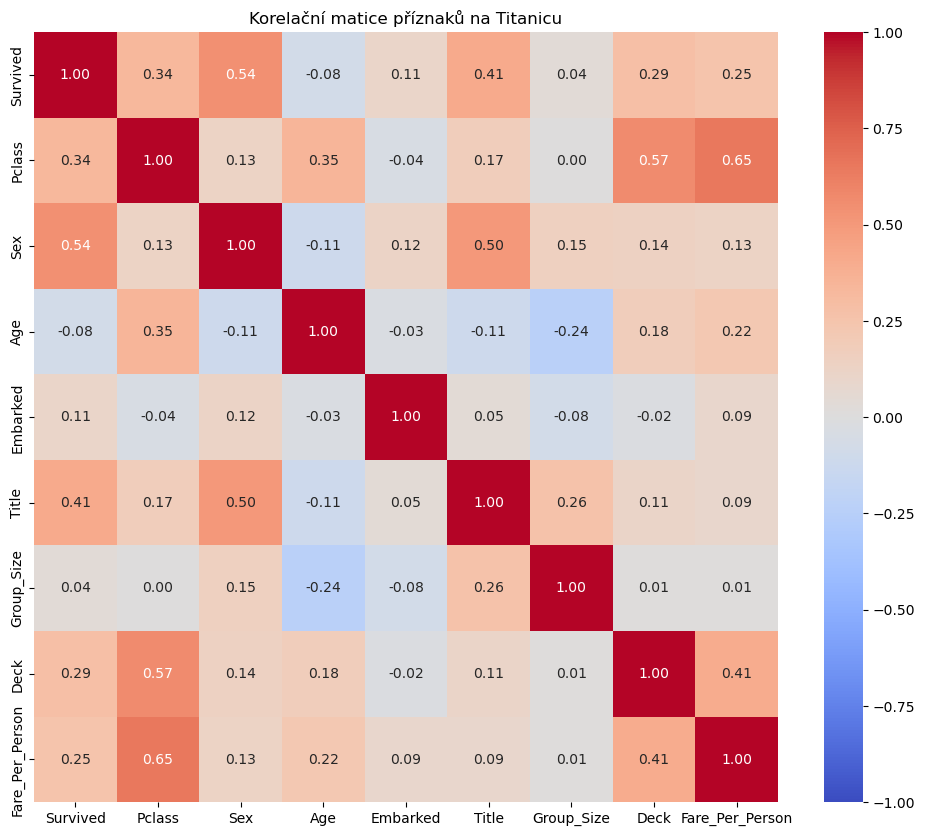

In [17]:
import pandas as pd
train_raw = pd.read_csv('data/train.csv', index_col=0)
test_raw = pd.read_csv('data/test.csv', index_col=0)
def preprocess_titanic_data(df, is_train=True, age_medians=None):
    df_clean = df.copy()

    # --- TVŮJ PŮVODNÍ PREPROCESSING ---
    df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
    df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    # 0. Pclass: Obrácení tříd (Tvůj nápad: vyšší hodnota = lepší třída)
    # 1. třída -> 3, 2. třída -> 2, 3. třída -> 1
    df_clean['Pclass'] = df_clean['Pclass'].map({1: 3, 2: 2, 3: 1})

    if is_train:
        df_clean = df_clean.dropna(subset=['Embarked'])
    else: # Vráceno: ošetření pro Kaggle test sadu
        df_clean['Embarked'] = df_clean['Embarked'].fillna(0)

    df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df_clean['Title'] = df_clean['Title'].replace(['Mlle', 'Ms'], 'Miss')
    df_clean['Title'] = df_clean['Title'].replace('Mme', 'Mrs')
    rare_titles = ['Don', 'Rev', 'Dr', 'Major', 'Lady', 'Sir', 'Col', 'Capt', 'the', 'Jonkheer', 'Countess', 'Dona'] 
    df_clean['Title'] = df_clean['Title'].replace(rare_titles, 'Rare')
    title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
    df_clean['Title'] = df_clean['Title'].map(title_mapping).fillna(0) 
    df_clean.drop(columns=['Name'], inplace=True) 

    pocty_listku = df_clean['Ticket'].value_counts()
    df_clean['Group_Size'] = df_clean['Ticket'].map(pocty_listku)
    df_clean.drop(columns=['Ticket'], inplace=True) 

    # Kajuty - Tady perfektně využíváš to, že nula = nemá kajutu = malá šance na přežití
    df_clean['Deck'] = df_clean['Cabin'].str.extract(r'([A-Za-z])', expand=False)
    cabin_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "T": 8}
    df_clean['Deck'] = df_clean['Deck'].map(cabin_mapping).fillna(0) 
    df_clean.drop(columns=['Cabin'], inplace=True) 

    if is_train:
        age_medians = df_clean.groupby('Title')['Age'].median().to_dict()
        df_clean['Age'] = df_clean['Age'].fillna(df_clean['Title'].map(age_medians))
    else: # Vráceno: doplňování věku z mediánů tréninku pro testovací sadu
        df_clean['Age'] = df_clean['Age'].fillna(df_clean['Title'].map(age_medians))

    if not is_train:
        df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

    # --- TVÉ NOVÉ NÁPADY ---
    
    # Výpočet reálné ceny na osobu
    df_clean['Fare_Per_Person'] = df_clean['Fare'] / df_clean['Group_Size']
    
    # Dobrá úvaha (volitelné): Protože už máme Fare_Per_Person a Group_Size, 
    # původní Fare by mohlo modely (zvlášť ty lineární) mást, protože by to byla duplicitní informace.
    df_clean.drop(columns=['Fare'], inplace=True)
    df_clean.drop(columns=['SibSp', 'Parch'], inplace=True) # nepřináší novou informaci, protože už máme Group_Size

    if is_train:
        return df_clean, age_medians
    return df_clean

# # 1. Zpracování trénovacích dat (získáme vyčištěný DataFrame a mediány věku)
train_clean, learned_age_medians = preprocess_titanic_data(train_raw, is_train=True)
train_clean.head(20)

číselná_data = train_clean.select_dtypes(include=['int64', 'float64'])

# 2. Samotný výpočet korelační matice (Pearsonův koeficient)
korelacni_matice = číselná_data.corr()

# 3. Vizualizace pomocí teplotní mapy
plt.figure(figsize=(12, 10)) # Nastavení velikosti grafu

# Vykreslení heatmapy:
# annot=True zobrazí čísla, cmap nastaví barvy (od modré po červenou), 
# fmt=".2f" zaokrouhlí na 2 desetinná místa
sns.heatmap(korelacni_matice, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Korelační matice příznaků na Titanicu')
plt.show()
# # 2. Zpracování testovacích dat (předáme funkci naučené mediány z tréninku)
# test_clean = preprocess_titanic_data(test_raw, is_train=False, age_medians=learned_age_medians)


🧠 TRÉNINK NEURONOVÉ SÍTĚ (PyTorch Lightning)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/luky/.local/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


✅ Hotovo! Nejlepší přesnost na validační sadě: 88.64 %
📁 Predikce NN uloženy do 'submission_pytorch.csv'.

📈 TRÉNINK SVM (Support Vector Machine)
✅ Hotovo! Nejlepší přesnost: 86.36 % (Parametry: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'})

📍 TRÉNINK KNN (K-Nearest Neighbors)
✅ Hotovo! Nejlepší přesnost: 86.36 % (K=4)


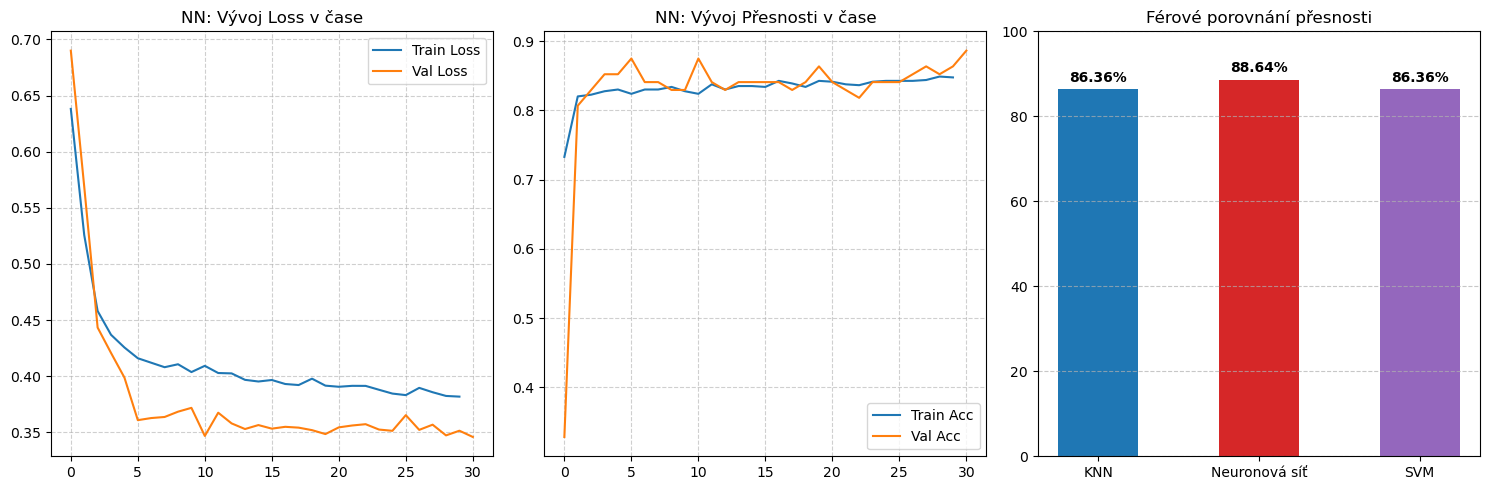

In [22]:
# 1. Zpracování dat tvou (nově upravenou) funkcí
train_clean, learned_age_medians = preprocess_titanic_data(train_raw, is_train=True)
test_clean = preprocess_titanic_data(test_raw, is_train=False, age_medians=learned_age_medians)

# 2. Spuštění celého experimentu a vykreslení!
run_all_experiments(train_clean, test_clean)